### 1. Import Libraries

In [1]:
# ============================================================
# Install Packages (Run Once)
# ============================================================

!pip install -q optuna xgboost lightgbm catboost shap psutil

# ============================================================
# Core Libraries
# ============================================================

import random
import warnings
import time
import psutil
import os

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

# ============================================================
# Visualization
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

# ============================================================
# Machine Learning
# ============================================================

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_predict
)

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.pipeline import Pipeline

# ============================================================
# Models
# ============================================================

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier
)

from sklearn.svm import SVC

from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

# ============================================================
# Calibration
# ============================================================

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)

# ============================================================
# Metrics
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# ============================================================
# Statistical Tests
# ============================================================

from scipy.stats import wilcoxon

# ============================================================
# Hyperparameter Optimization
# ============================================================

import optuna

from optuna.samplers import TPESampler

# ============================================================
# Explainability
# ============================================================

import shap

print("="*60)
print("Environment Ready")
print("Random Seed :", SEED)
print("="*60)

Environment Ready
Random Seed : 42


In [2]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Models
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

# Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Optimization
import optuna

# Metrics
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score
)

# Calibration
from sklearn.calibration import CalibratedClassifierCV

# Explainability
import shap

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

### 2. Load Dataset

In [3]:
data = pd.read_csv("train.csv")

print("Shape:", data.shape)
data.head()

Shape: (700000, 26)


,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


### 3. Basic Data Inspection

In [4]:
print(data.info())

print("\nMissing values:\n", data.isnull().sum())

print("\nTarget distribution:")
print(data['diagnosed_diabetes'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

### 4. Data Preprocessing

In [5]:
# ============================================================
# Data Preparation
# ============================================================

TARGET = "diagnosed_diabetes"

# Remove target and ID
X = data.drop(columns=[TARGET, "id"])
y = data[TARGET]

print("=" * 60)
print("Original Dataset Shape")
print("=" * 60)
print("Features :", X.shape)
print("Target   :", y.shape)

# ============================================================
# Feature Types
# ============================================================

num_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

cat_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nNumerical Features :", len(num_cols))
print("Categorical Features :", len(cat_cols))

# ============================================================
# Preprocessing Pipelines
# ============================================================

numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# ============================================================
# Combined Preprocessor
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols)
    ],
    remainder="drop"
)

# ============================================================
# Transform Features
# ============================================================

X_processed = preprocessor.fit_transform(X)

# Convert to DataFrame
feature_names = preprocessor.get_feature_names_out()

feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]

X_processed = pd.DataFrame(
    X_processed,
    columns=feature_names
)

print("\nProcessed Shape :", X_processed.shape)

print("=" * 60)
print("Preprocessing Completed")
print("=" * 60)

Original Dataset Shape
Features : (700000, 24)
Target   : (700000,)

Numerical Features : 18
Categorical Features : 6

Processed Shape : (700000, 42)
Preprocessing Completed


### 5. Train-Test Split

In [6]:
# ============================================================
# Train-Test Split
# ============================================================

TEST_SIZE = 0.20

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SEED,
    shuffle=True
)

print("=" * 60)
print("Train/Test Split")
print("=" * 60)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

print("\nTraining Distribution")
print(y_train.value_counts(normalize=True))

print("\nTesting Distribution")
print(y_test.value_counts(normalize=True))

print("=" * 60)

# ============================================================
# Cross Validation Strategy
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

print("5-Fold Stratified Cross Validation Ready")

Train/Test Split
Training Samples : 560000
Testing Samples  : 140000

Training Distribution
diagnosed_diabetes
1.0    0.623296
0.0    0.376704
Name: proportion, dtype: float64

Testing Distribution
diagnosed_diabetes
1.0    0.623293
0.0    0.376707
Name: proportion, dtype: float64
5-Fold Stratified Cross Validation Ready


### 6. Optuna Tuning – XGBoost

In [7]:
# ============================================================
# XGBoost Hyperparameter Optimization (Journal Version)
# ============================================================

print("=" * 60)
print("Optimizing XGBoost using Optuna")
print("=" * 60)

# ------------------------------------------------------------
# Objective Function
# ------------------------------------------------------------

def objective_xgb(trial):

    params = {

        "n_estimators": trial.suggest_int("n_estimators", 100, 500),

        "max_depth": trial.suggest_int("max_depth", 3, 10),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.20,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.60,
            1.00
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.60,
            1.00
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            5
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0.5,
            5
        ),

        "objective": "binary:logistic",

        "eval_metric": "logloss",

        "random_state": SEED,

        "n_jobs": -1
    }

    cv_scores = []

    for train_idx, valid_idx in cv.split(X_train, y_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[valid_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[valid_idx]

        model = XGBClassifier(**params)

        model.fit(
            X_tr,
            y_tr,
            verbose=False
        )

        probs = model.predict_proba(X_val)[:,1]

        score = roc_auc_score(
            y_val,
            probs
        )

        cv_scores.append(score)

    return np.mean(cv_scores)

# ------------------------------------------------------------
# Create Study
# ------------------------------------------------------------

sampler = TPESampler(seed=SEED)

study_xgb = optuna.create_study(

    direction="maximize",

    sampler=sampler

)

# ------------------------------------------------------------
# Optimize
# ------------------------------------------------------------

start_time = time.time()

study_xgb.optimize(

    objective_xgb,

    n_trials=50,

    show_progress_bar=True

)

xgb_time = time.time() - start_time

print("\nOptimization Finished")

print("Best ROC-AUC :", study_xgb.best_value)

print("\nBest Parameters")

for k, v in study_xgb.best_params.items():
    print(f"{k} : {v}")

print("\nTraining Final XGBoost Model...")

# ------------------------------------------------------------
# Train Final Model
# ------------------------------------------------------------

best_xgb = XGBClassifier(

    **study_xgb.best_params,

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=SEED,

    n_jobs=-1

)

best_xgb.fit(

    X_train,

    y_train

)

print("\nFinal XGBoost Model Ready")

print(f"Optimization Time : {xgb_time:.2f} seconds")

[I 2026-07-03 09:24:27,742] A new study created in memory with name: no-name-8196a8d8-c7bf-48b0-8560-503541733352


Optimizing XGBoost using Optuna


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-03 09:24:48,951] Trial 0 finished with value: 0.7237144667325168 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.08960785365368121, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 4.330880728874676, 'reg_lambda': 3.20501755284444}. Best is trial 0 with value: 0.7237144667325168.
[I 2026-07-03 09:25:05,734] Trial 1 finished with value: 0.725304904978245 and parameters: {'n_estimators': 383, 'max_depth': 3, 'learning_rate': 0.18276027831785724, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'reg_alpha': 1.5212112147976886, 'reg_lambda': 2.86140394234507}. Best is trial 1 with value: 0.725304904978245.
[I 2026-07-03 09:25:21,482] Trial 2 finished with value: 0.7214158426734506 and parameters: {'n_estimators': 273, 'max_depth': 5, 'learning_rate': 0.06252287916406217, 'subsample': 0.65579

### 7. Optuna Tuning – LightGBM

In [8]:
# ============================================================
# LightGBM Hyperparameter Optimization (Journal Version)
# ============================================================

print("=" * 60)
print("Optimizing LightGBM using Optuna")
print("=" * 60)

# ------------------------------------------------------------
# Objective Function
# ------------------------------------------------------------

def objective_lgb(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            500
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.20,
            log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            12
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves",
            20,
            200
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            10,
            100
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.60,
            1.00
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.60,
            1.00
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            5
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0,
            5
        ),

        "random_state": SEED,

        "n_jobs": -1,

        "verbose": -1
    }

    cv_scores = []

    for train_idx, valid_idx in cv.split(X_train, y_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[valid_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[valid_idx]

        model = LGBMClassifier(**params)

        model.fit(
            X_tr,
            y_tr
        )

        probs = model.predict_proba(X_val)[:,1]

        score = roc_auc_score(
            y_val,
            probs
        )

        cv_scores.append(score)

    return np.mean(cv_scores)

# ------------------------------------------------------------
# Create Study
# ------------------------------------------------------------

sampler = TPESampler(seed=SEED)

study_lgb = optuna.create_study(

    direction="maximize",

    sampler=sampler

)

# ------------------------------------------------------------
# Optimize
# ------------------------------------------------------------

start_time = time.time()

study_lgb.optimize(

    objective_lgb,

    n_trials=50,

    show_progress_bar=True

)

lgb_time = time.time() - start_time

print("\nOptimization Finished")

print("Best ROC-AUC :", study_lgb.best_value)

print("\nBest Parameters")

for k, v in study_lgb.best_params.items():
    print(f"{k} : {v}")

print("\nTraining Final LightGBM Model...")

# ------------------------------------------------------------
# Train Final Model
# ------------------------------------------------------------

best_lgb = LGBMClassifier(

    **study_lgb.best_params,

    random_state=SEED,

    n_jobs=-1,

    verbose=-1

)

best_lgb.fit(

    X_train,

    y_train

)

print("\nFinal LightGBM Model Ready")

print(f"Optimization Time : {lgb_time:.2f} seconds")

[I 2026-07-03 09:40:21,089] A new study created in memory with name: no-name-d1367849-a120-4553-a4b7-b4e59be6b6b4


Optimizing LightGBM using Optuna


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-03 09:40:36,018] Trial 0 finished with value: 0.7238583195240563 and parameters: {'n_estimators': 250, 'learning_rate': 0.17254716573280354, 'max_depth': 10, 'num_leaves': 128, 'min_child_samples': 24, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 4.330880728874676, 'reg_lambda': 3.005575058716044}. Best is trial 0 with value: 0.7238583195240563.
[I 2026-07-03 09:41:11,475] Trial 1 finished with value: 0.7227534803894166 and parameters: {'n_estimators': 383, 'learning_rate': 0.010636066512540286, 'max_depth': 12, 'num_leaves': 170, 'min_child_samples': 29, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 1.5212112147976886, 'reg_lambda': 2.6237821581611893}. Best is trial 0 with value: 0.7238583195240563.
[I 2026-07-03 09:41:24,840] Trial 2 finished with value: 0.7203966008715624 and parameters: {'n_estimators': 273, 'learning_rate': 0.023927528765580644, 'max_depth': 9, 'num_leaves': 45, 'min_child_

### 8. Train MLP Model

In [9]:
# ============================================================
# Multi-Layer Perceptron (Improved Version)
# ============================================================

print("=" * 60)
print("Training Multi-Layer Perceptron")
print("=" * 60)

start_time = time.time()

mlp = MLPClassifier(

    hidden_layer_sizes=(128, 64),

    activation="relu",

    solver="adam",

    alpha=0.0005,

    batch_size=512,

    learning_rate="adaptive",

    learning_rate_init=0.001,

    max_iter=300,

    shuffle=True,

    early_stopping=True,

    validation_fraction=0.10,

    n_iter_no_change=15,

    random_state=SEED

)

mlp.fit(
    X_train,
    y_train
)

mlp_time = time.time() - start_time

print("\nMLP Training Completed")

print("Iterations :", mlp.n_iter_)

print("Training Time :", round(mlp_time,2),"seconds")

Training Multi-Layer Perceptron

MLP Training Completed
Iterations : 20
Training Time : 75.27 seconds


### Comparison table

In [10]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "XGBoost": best_xgb,
    "LightGBM": best_lgb,
    "MLP": mlp
}

results = []

for name, model in models.items():

    probs = model.predict_proba(X_test)[:,1]
    preds = (probs > 0.5).astype(int)

    results.append([
        name,
        precision_score(y_test, preds),
        recall_score(y_test, preds),
        f1_score(y_test, preds),
        roc_auc_score(y_test, probs)
    ])

comparison_df = pd.DataFrame(
    results,
    columns=["Model", "Precision", "Recall", "F1-Score", "ROC-AUC"]
)

comparison_df

,Model,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.707244,0.841430,0.768524,0.726488
1,LightGBM,0.708830,0.839928,0.768831,0.727318
2,MLP,0.678694,0.875385,0.764593,0.694821


### 9. Generate Meta Features (Stacking Input)

In [11]:
# ============================================================
# Proper Out-of-Fold Stacking
# ============================================================

from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression

print("="*60)
print("Generating Out-of-Fold Predictions")
print("="*60)

# ------------------------------------------------------------
# OOF Predictions for Training Set
# ------------------------------------------------------------

xgb_oof = cross_val_predict(
    best_xgb,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:,1]

lgb_oof = cross_val_predict(
    best_lgb,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:,1]

mlp_oof = cross_val_predict(
    mlp,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:,1]

# ------------------------------------------------------------
# Meta Features
# ------------------------------------------------------------

meta_X_train = pd.DataFrame({

    "XGB": xgb_oof,

    "LGBM": lgb_oof,

    "MLP": mlp_oof

})

# ------------------------------------------------------------
# Test Meta Features
# ------------------------------------------------------------

meta_X_test = pd.DataFrame({

    "XGB": best_xgb.predict_proba(X_test)[:,1],

    "LGBM": best_lgb.predict_proba(X_test)[:,1],

    "MLP": mlp.predict_proba(X_test)[:,1]

})

print(meta_X_train.head())

print("\nShape :",meta_X_train.shape)

print("="*60)

Generating Out-of-Fold Predictions
        XGB      LGBM       MLP
0  0.617107  0.573126  0.567927
1  0.773334  0.794234  0.721663
2  0.594700  0.591608  0.569392
3  0.667427  0.670291  0.660863
4  0.908093  0.898390  0.896634

Shape : (560000, 3)


### 10. Meta Learner (xgboost)

In [12]:
# ============================================================
# Hyperparameter Tuning - Logistic Regression Meta Learner
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

print("=" * 60)
print("Optimizing Logistic Regression Meta Learner")
print("=" * 60)

param_grid = {

    "C":[
        0.001,
        0.01,
        0.1,
        1,
        5,
        10,
        50,
        100
    ]

}

grid = GridSearchCV(

    LogisticRegression(

        solver="lbfgs",

        max_iter=2000,

        random_state=SEED

    ),

    param_grid=param_grid,

    scoring="roc_auc",

    cv=cv,

    n_jobs=-1

)

grid.fit(

    meta_X_train,

    y_train

)

meta_model = grid.best_estimator_

print("\nBest C :",grid.best_params_)

print("Best CV ROC :",grid.best_score_)

Optimizing Logistic Regression Meta Learner

Best C : {'C': 100}
Best CV ROC : 0.7280909832314981


### 11. Probability Calibration (Isotonic)

In [13]:
from sklearn.calibration import CalibratedClassifierCV

# ============================================================
# Probability Calibration
# ============================================================

calibrated_model = CalibratedClassifierCV(

    estimator=meta_model,

    method="isotonic",

    cv=5
)

calibrated_model.fit(

    meta_X_train,

    y_train

)

final_probs = calibrated_model.predict_proba(

    meta_X_test

)[:,1]

from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_test,
    final_probs
)

f1_scores = (2 * precision_curve[:-1] * recall_curve[:-1]) / (
    precision_curve[:-1] + recall_curve[:-1] + 1e-8
)

best_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold :",best_threshold)

final_preds = (final_probs >= best_threshold).astype(int)

Best Threshold : 0.38068604834985476


### 12. Final Evaluation

In [ ]:
# ============================================================
# Final Evaluation
# ============================================================

roc = roc_auc_score(y_test, final_probs)

precision = precision_score(y_test, final_preds)

recall = recall_score(y_test, final_preds)

f1 = f1_score(y_test, final_preds)

print("="*60)

print("Stacking Ensemble Performance")

print("="*60)

print("ROC-AUC :",round(roc,5))

print("Precision :",round(precision,5))

print("Recall :",round(recall,5))

print("F1 :",round(f1,5))

Stacking Ensemble Performance
ROC-AUC : 0.72776
Precision : 0.66681
Recall : 0.94361
F1 : 0.78142


In [15]:
comparison_df = comparison_df.copy()

comparison_df.loc[len(comparison_df)] = [

    "Proposed Stacking Ensemble",

    precision,

    recall,

    f1,

    roc

]

comparison_df

,Model,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.707244,0.841430,0.768524,0.726488
1,LightGBM,0.708830,0.839928,0.768831,0.727318
2,MLP,0.678694,0.875385,0.764593,0.694821
3,Proposed Stacking Ensemble,0.666812,0.943606,0.781422,0.727761


### confusion matrix

<Figure size 600x500 with 0 Axes>

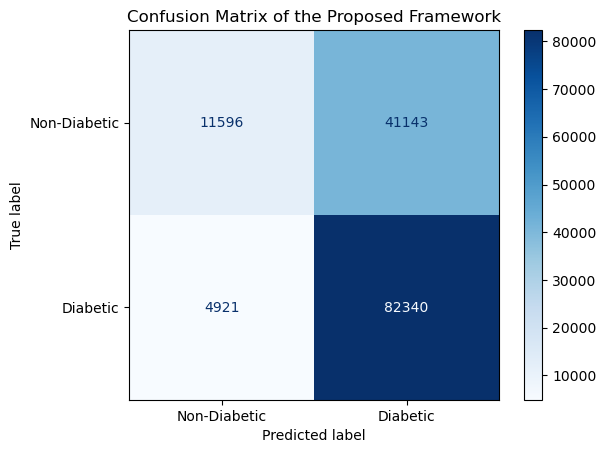

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Diabetic", "Diabetic"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix of the Proposed Framework")
plt.show()

### 13. ROC Curve

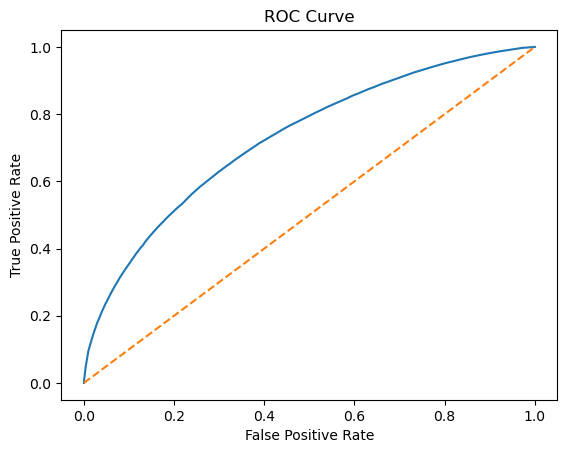

In [17]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, final_probs)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

### calibration curve and score

Brier Score: 0.19978473359818952


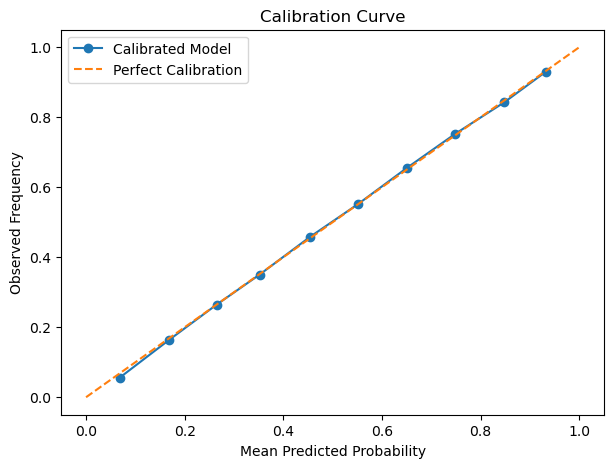

In [18]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Brier Score
brier = brier_score_loss(y_test, final_probs)
print("Brier Score:", brier)

# Calibration Curve
prob_true, prob_pred = calibration_curve(
    y_test,
    final_probs,
    n_bins=10
)

plt.figure(figsize=(7,5))
plt.plot(prob_pred, prob_true, marker='o', label='Calibrated Model')
plt.plot([0,1], [0,1], linestyle='--', label='Perfect Calibration')

plt.title("Calibration Curve")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.legend()

plt.show()

Advanced Calibration Analysis


,Metric,Before Calibration,After Calibration
0,Brier Score,0.20009,0.199785
1,Expected Calibration Error (ECE),0.01433,0.003220


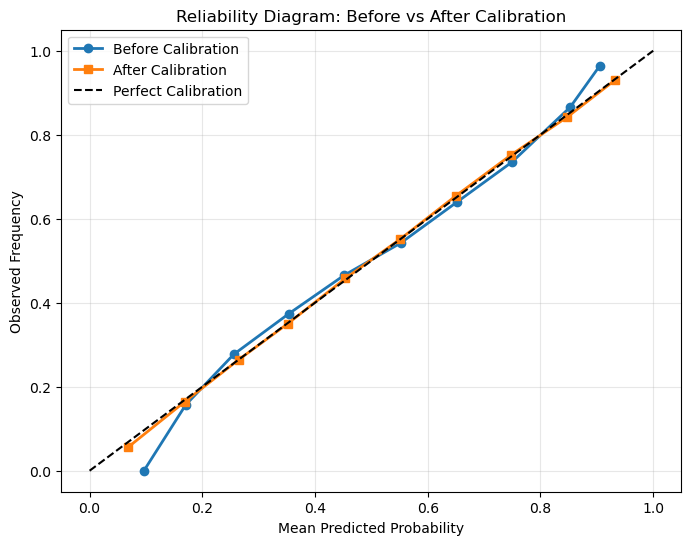



✓ Brier Score improved after calibration.
✓ Expected Calibration Error improved after calibration.


In [19]:
# ============================================================
# Advanced Calibration Analysis
# ============================================================

print("=" * 70)
print("Advanced Calibration Analysis")
print("=" * 70)

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# ------------------------------------------------------------
# BEFORE Calibration
# ------------------------------------------------------------

before_probs = meta_model.predict_proba(meta_X_test)[:, 1]

before_brier = brier_score_loss(
    y_test,
    before_probs
)

# ------------------------------------------------------------
# AFTER Calibration
# ------------------------------------------------------------

after_probs = final_probs

after_brier = brier_score_loss(
    y_test,
    after_probs
)

# ------------------------------------------------------------
# Expected Calibration Error (ECE)
# ------------------------------------------------------------

def calculate_ece(y_true, y_prob, n_bins=10):

    bins = np.linspace(0.0, 1.0, n_bins + 1)

    binids = np.digitize(y_prob, bins) - 1

    ece = 0.0

    for i in range(n_bins):

        mask = binids == i

        if np.sum(mask) == 0:
            continue

        avg_confidence = np.mean(y_prob[mask])

        avg_accuracy = np.mean(y_true[mask])

        weight = np.sum(mask) / len(y_true)

        ece += weight * abs(avg_accuracy - avg_confidence)

    return ece


before_ece = calculate_ece(
    y_test.values,
    before_probs
)

after_ece = calculate_ece(
    y_test.values,
    after_probs
)

# ------------------------------------------------------------
# Results Table
# ------------------------------------------------------------

calibration_results = pd.DataFrame({

    "Metric": [
        "Brier Score",
        "Expected Calibration Error (ECE)"
    ],

    "Before Calibration": [
        before_brier,
        before_ece
    ],

    "After Calibration": [
        after_brier,
        after_ece
    ]

})

display(calibration_results)

# ------------------------------------------------------------
# Reliability Diagram
# ------------------------------------------------------------

true_before, pred_before = calibration_curve(
    y_test,
    before_probs,
    n_bins=10
)

true_after, pred_after = calibration_curve(
    y_test,
    after_probs,
    n_bins=10
)

plt.figure(figsize=(8,6))

plt.plot(
    pred_before,
    true_before,
    marker="o",
    linewidth=2,
    label="Before Calibration"
)

plt.plot(
    pred_after,
    true_after,
    marker="s",
    linewidth=2,
    label="After Calibration"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="black",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")

plt.ylabel("Observed Frequency")

plt.title("Reliability Diagram: Before vs After Calibration")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# ------------------------------------------------------------
# Interpretation
# ------------------------------------------------------------

print("\n")
print("=" * 70)

if after_brier < before_brier:
    print("✓ Brier Score improved after calibration.")
else:
    print("⚠ No improvement in Brier Score after calibration.")

if after_ece < before_ece:
    print("✓ Expected Calibration Error improved after calibration.")
else:
    print("⚠ No improvement in Expected Calibration Error.")

print("=" * 70)

### 14. Explainable AI (SHAP)

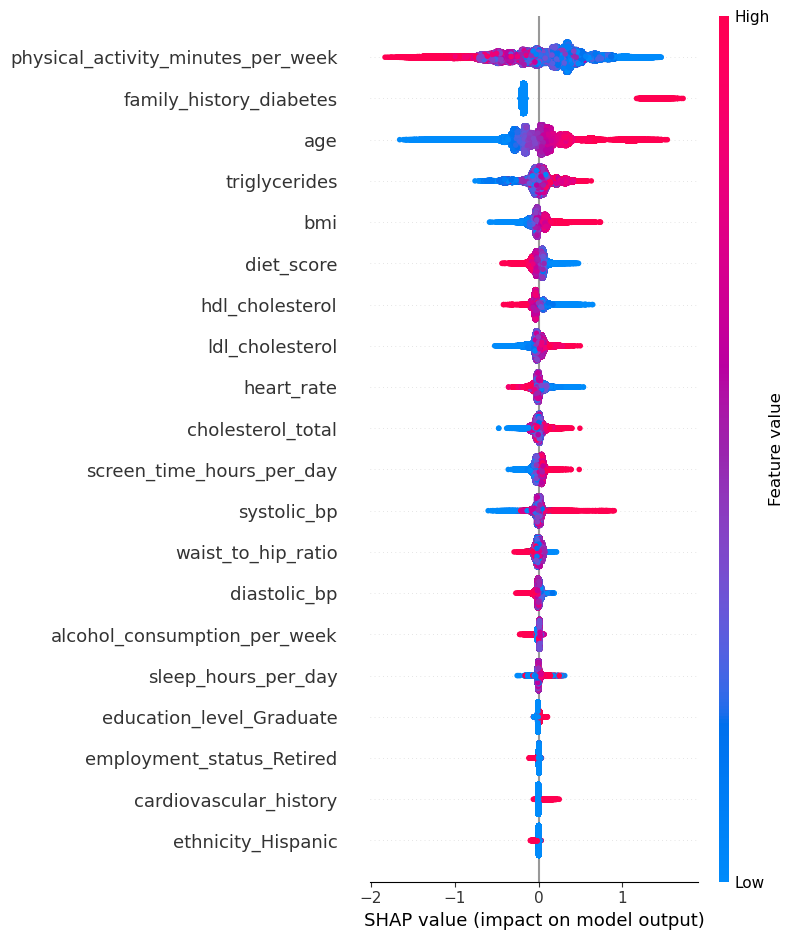

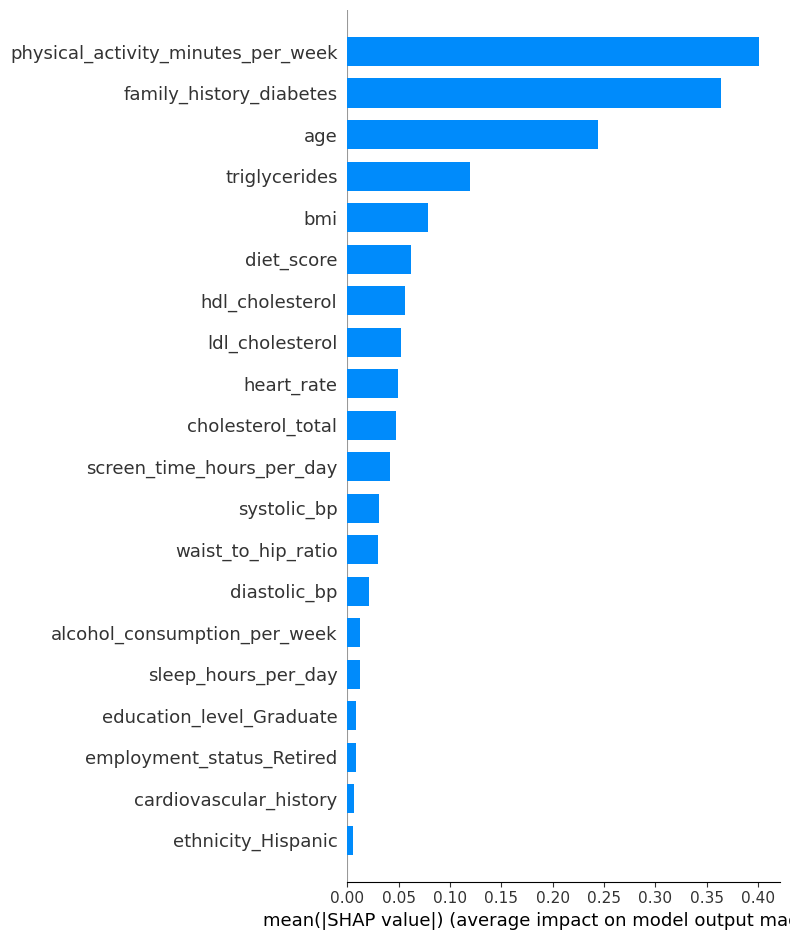

In [20]:
# -----------------------------
# SHAP Explainability Analysis
# -----------------------------

feature_names = preprocessor.get_feature_names_out()

# Remove num__ and cat__ prefixes
feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]

# Convert X_test into a DataFrame with proper column names
if hasattr(X_test, "toarray"):
    X_test_df = pd.DataFrame(
        X_test.toarray(),
        columns=feature_names
    )
else:
    X_test_df = pd.DataFrame(
        X_test,
        columns=feature_names
    )

# Create SHAP explainer
explainer = shap.Explainer(best_xgb)

# Compute SHAP values
shap_values = explainer(X_test_df)

# Beeswarm plot
shap.summary_plot(
    shap_values,
    X_test_df,
    show=True
)

# Optional: Feature importance bar plot
shap.summary_plot(
    shap_values,
    X_test_df,
    plot_type="bar",
    show=True
)

SHAP Dependence Plots

Top 10 Most Important Features


,Feature,Importance
2,physical_activity_minutes_per_week,0.401117
15,family_history_diabetes,0.364135
0,age,0.244526
14,triglycerides,0.119436
6,bmi,0.078192
3,diet_score,0.062442
12,hdl_cholesterol,0.056505
13,ldl_cholesterol,0.052368
10,heart_rate,0.049298
11,cholesterol_total,0.047013



Generating Dependence Plots...

Feature : physical_activity_minutes_per_week


<Figure size 700x500 with 0 Axes>

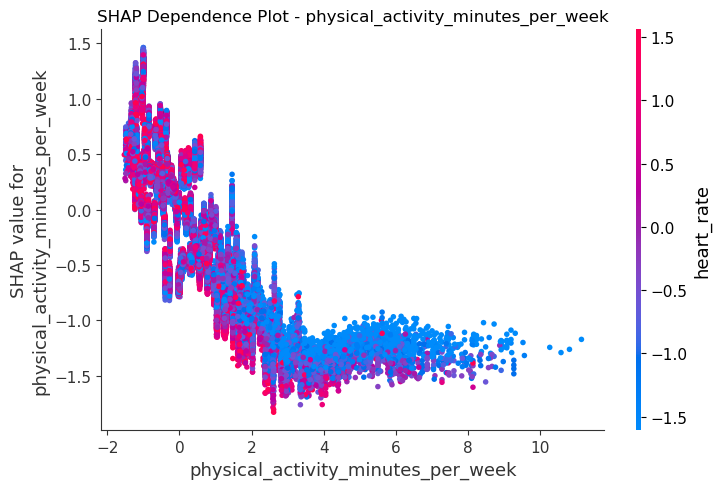

Feature : family_history_diabetes


<Figure size 700x500 with 0 Axes>

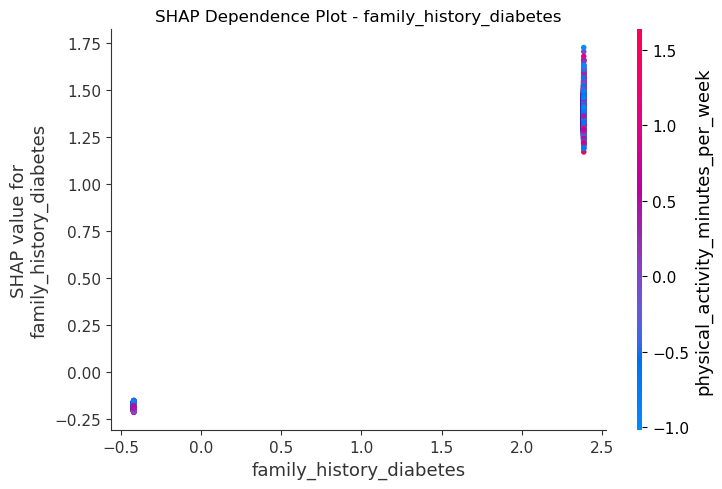

Feature : age


<Figure size 700x500 with 0 Axes>

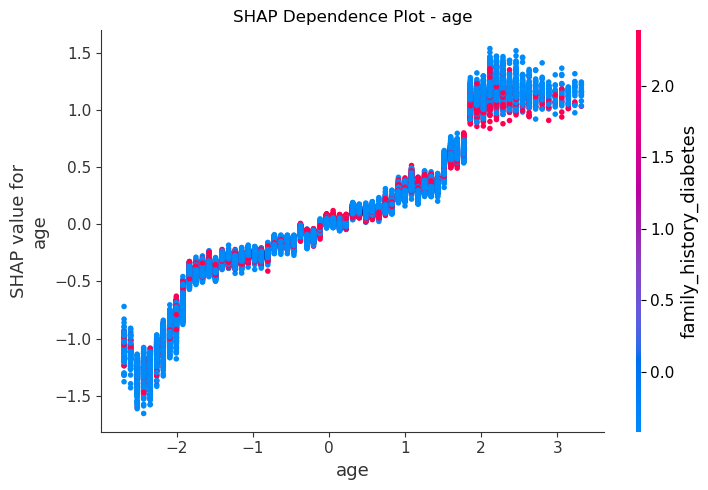

Feature : triglycerides


<Figure size 700x500 with 0 Axes>

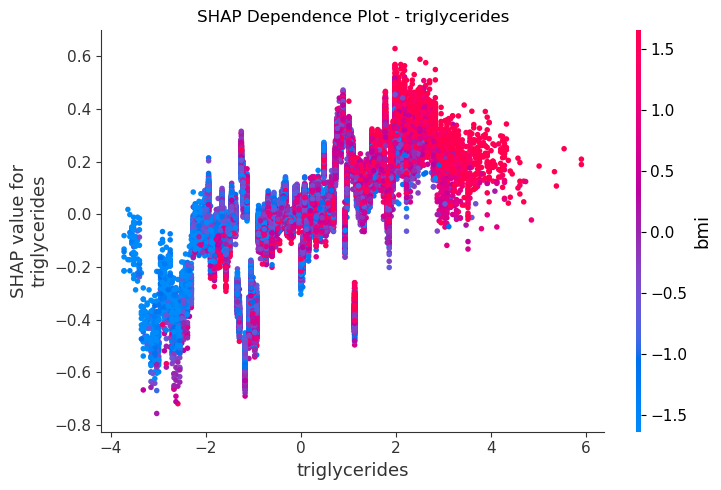

Feature : bmi


<Figure size 700x500 with 0 Axes>

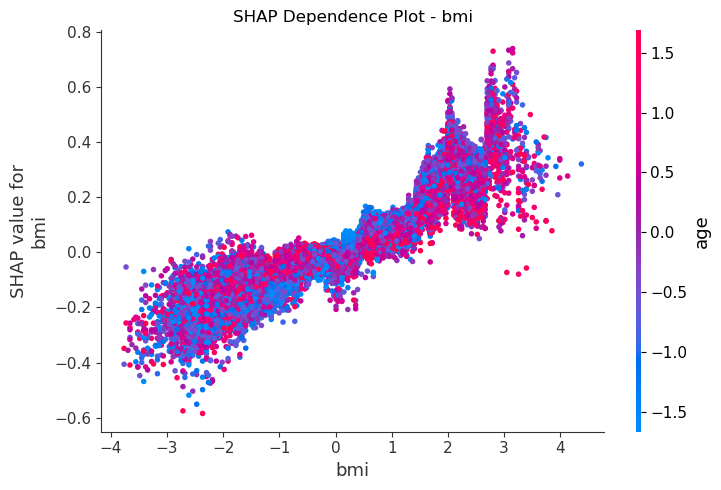

In [21]:
# ============================================================
# SHAP Dependence Plots
# ============================================================

print("="*60)
print("SHAP Dependence Plots")
print("="*60)

import numpy as np

# ------------------------------------------------------------
# Calculate mean absolute SHAP values
# ------------------------------------------------------------

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": X_test_df.columns,
    "Importance": mean_abs_shap
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Most Important Features")
display(importance_df.head(10))

# ------------------------------------------------------------
# Select Top 5 Features
# ------------------------------------------------------------

top_features = importance_df["Feature"].head(5).tolist()

print("\nGenerating Dependence Plots...\n")

# ------------------------------------------------------------
# Generate Dependence Plot
# ------------------------------------------------------------

for feature in top_features:

    print(f"Feature : {feature}")

    plt.figure(figsize=(7,5))

    shap.dependence_plot(
        feature,
        shap_values.values,
        X_test_df,
        interaction_index="auto",
        show=False
    )

    plt.title(f"SHAP Dependence Plot - {feature}")

    plt.tight_layout()

    plt.show()

SHAP Waterfall Plot


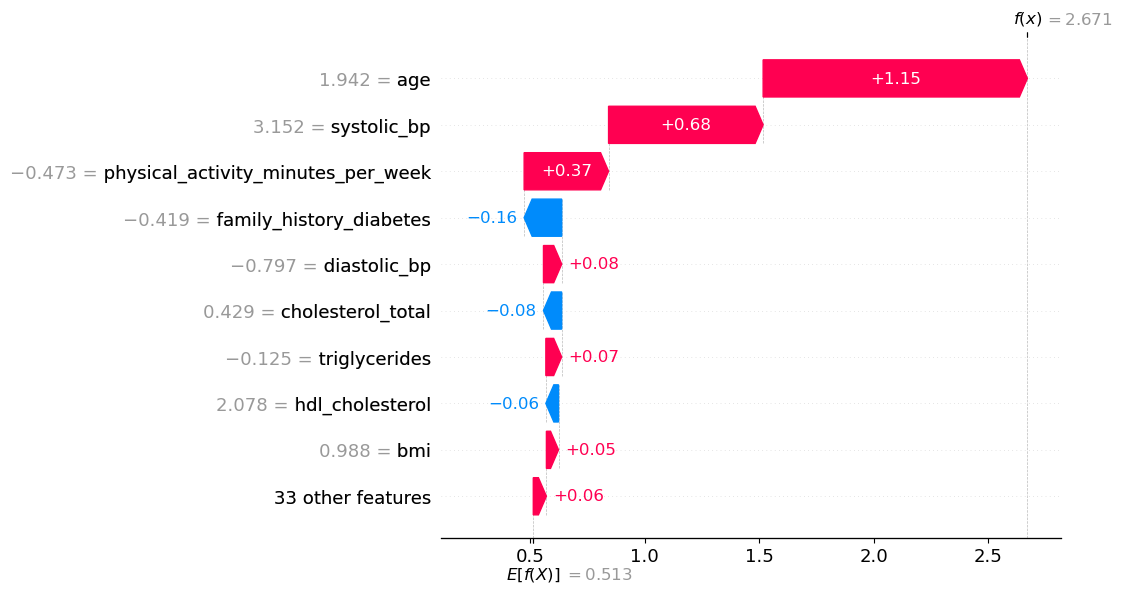


Patient Index : 0
Predicted Probability : 0.9353
Predicted Class       : 1
Actual Class          : 1.0


In [22]:
# ============================================================
# SHAP Waterfall Plot (Local Explanation)
# ============================================================

print("=" * 60)
print("SHAP Waterfall Plot")
print("=" * 60)

# ------------------------------------------------------------
# Select a patient/sample
# Change sample_index if you want another patient
# ------------------------------------------------------------

sample_index = 0

# ------------------------------------------------------------
# Waterfall Plot
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

shap.plots.waterfall(
    shap_values[sample_index],
    max_display=10
)

plt.show()

# ------------------------------------------------------------
# Display prediction information
# ------------------------------------------------------------

prediction_probability = best_xgb.predict_proba(
    X_test_df.iloc[[sample_index]]
)[0,1]

predicted_class = best_xgb.predict(
    X_test_df.iloc[[sample_index]]
)[0]

actual_class = y_test.iloc[sample_index]

print("\nPatient Index :", sample_index)
print(f"Predicted Probability : {prediction_probability:.4f}")
print(f"Predicted Class       : {predicted_class}")
print(f"Actual Class          : {actual_class}")

In [23]:
# ============================================================
# SHAP Force Plot (Local Explanation)
# ============================================================

print("=" * 60)
print("SHAP Force Plot")
print("=" * 60)

# ------------------------------------------------------------
# Select patient
# ------------------------------------------------------------

sample_index = np.argmax(final_probs)

# ------------------------------------------------------------
# Initialize SHAP JS
# ------------------------------------------------------------

shap.initjs()

# ------------------------------------------------------------
# Display Force Plot
# ------------------------------------------------------------

force_plot = shap.force_plot(
    base_value=explainer.expected_value,
    shap_values=shap_values.values[sample_index],
    features=X_test_df.iloc[sample_index],
    feature_names=X_test_df.columns,
    matplotlib=False
)

display(force_plot)

# ------------------------------------------------------------
# Prediction Details
# ------------------------------------------------------------

pred_prob = best_xgb.predict_proba(
    X_test_df.iloc[[sample_index]]
)[0,1]

pred_class = best_xgb.predict(
    X_test_df.iloc[[sample_index]]
)[0]

actual = y_test.iloc[sample_index]

print(f"\nPatient Index : {sample_index}")
print(f"Prediction Probability : {pred_prob:.4f}")
print(f"Predicted Class : {pred_class}")
print(f"Actual Class : {actual}")

SHAP Force Plot



Patient Index : 6573
Prediction Probability : 0.9890
Predicted Class : 1
Actual Class : 1.0


In [24]:
# ============================================================
# Case-Level Explanation
# ============================================================

print("=" * 60)
print("Case-Level Explanation")
print("=" * 60)

# Select the patient with the highest predicted probability
sample_index = np.argmax(final_probs)

prediction_probability = best_xgb.predict_proba(
    X_test_df.iloc[[sample_index]]
)[0, 1]

predicted_class = best_xgb.predict(
    X_test_df.iloc[[sample_index]]
)[0]

actual_class = y_test.iloc[sample_index]

print(f"\nPatient Index            : {sample_index}")
print(f"Predicted Probability    : {prediction_probability:.4f}")
print(f"Predicted Class          : {predicted_class}")
print(f"Actual Class             : {actual_class}")

# ------------------------------------------------------------
# Top Contributing Features
# ------------------------------------------------------------

case_df = pd.DataFrame({
    "Feature": X_test_df.columns,
    "Feature Value": X_test_df.iloc[sample_index].values,
    "SHAP Value": shap_values.values[sample_index]
})

case_df["Absolute SHAP"] = np.abs(case_df["SHAP Value"])

case_df = case_df.sort_values(
    by="Absolute SHAP",
    ascending=False
)

print("\nTop 10 Features Influencing This Prediction")

display(case_df.head(10))

Case-Level Explanation

Patient Index            : 6573
Predicted Probability    : 0.9890
Predicted Class          : 1
Actual Class             : 1.0

Top 10 Features Influencing This Prediction


,Feature,Feature Value,SHAP Value,Absolute SHAP
15,family_history_diabetes,2.386080,1.376853,1.376853
0,age,2.028248,0.969530,0.969530
2,physical_activity_minutes_per_week,-0.649102,0.702690,0.702690
14,triglycerides,2.624082,0.341314,0.341314
11,cholesterol_total,1.863698,0.222006,0.222006
13,ldl_cholesterol,2.685999,0.205370,0.205370
3,diet_score,-1.751953,0.185444,0.185444
12,hdl_cholesterol,0.626234,-0.089953,0.089953
6,bmi,2.211106,0.086014,0.086014
9,diastolic_bp,1.253936,-0.076398,0.076398


Comparative Explainability: High-Risk vs Low-Risk Patient

High-Risk Patient
Patient Index         : 6573
Predicted Probability : 0.9890
Predicted Class       : 1
Actual Class          : 1.0

Top 10 Contributing Features


,Feature,Feature Value,SHAP Value,Absolute SHAP
15,family_history_diabetes,2.386080,1.376853,1.376853
0,age,2.028248,0.969530,0.969530
2,physical_activity_minutes_per_week,-0.649102,0.702690,0.702690
14,triglycerides,2.624082,0.341314,0.341314
11,cholesterol_total,1.863698,0.222006,0.222006
13,ldl_cholesterol,2.685999,0.205370,0.205370
3,diet_score,-1.751953,0.185444,0.185444
12,hdl_cholesterol,0.626234,-0.089953,0.089953
6,bmi,2.211106,0.086014,0.086014
9,diastolic_bp,1.253936,-0.076398,0.076398



Waterfall Explanation


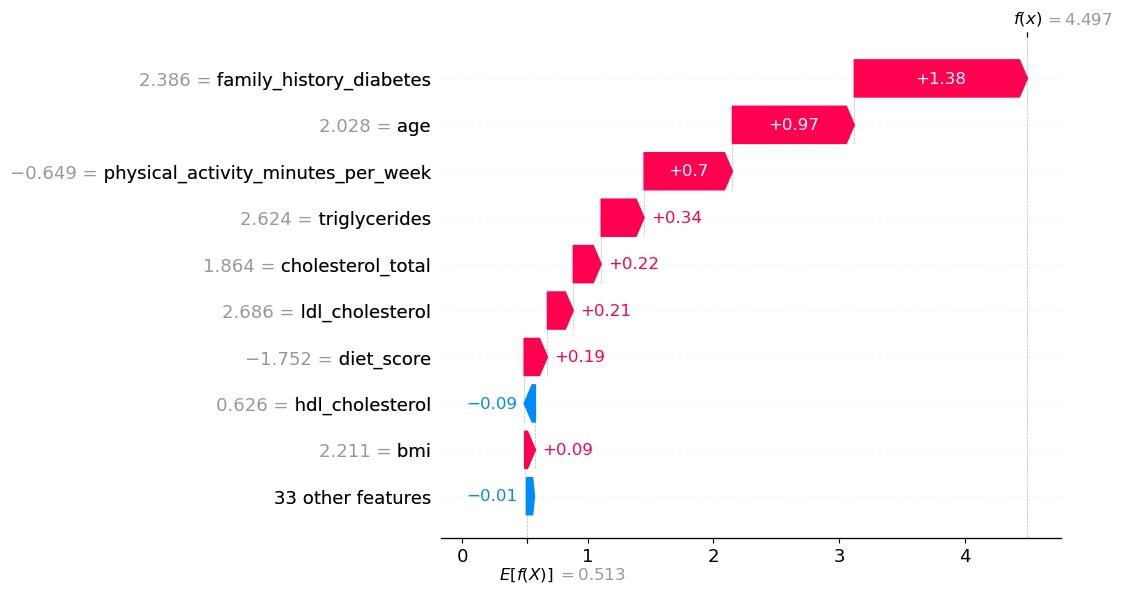


Low-Risk Patient
Patient Index         : 11022
Predicted Probability : 0.0601
Predicted Class       : 0
Actual Class          : 0.0

Top 10 Contributing Features


,Feature,Feature Value,SHAP Value,Absolute SHAP
2,physical_activity_minutes_per_week,2.476201,-1.295727,1.295727
0,age,-2.433161,-1.175246,1.175246
14,triglycerides,-1.013843,-0.309654,0.309654
10,heart_rate,1.561132,-0.216813,0.216813
15,family_history_diabetes,-0.419097,-0.187613,0.187613
13,ldl_cholesterol,-1.309291,-0.136456,0.136456
8,systolic_bp,-1.389070,0.086621,0.086621
9,diastolic_bp,1.253936,-0.053906,0.053906
3,diet_score,-0.795234,0.045804,0.045804
5,screen_time_hours_per_day,-0.995069,-0.042327,0.042327



Waterfall Explanation


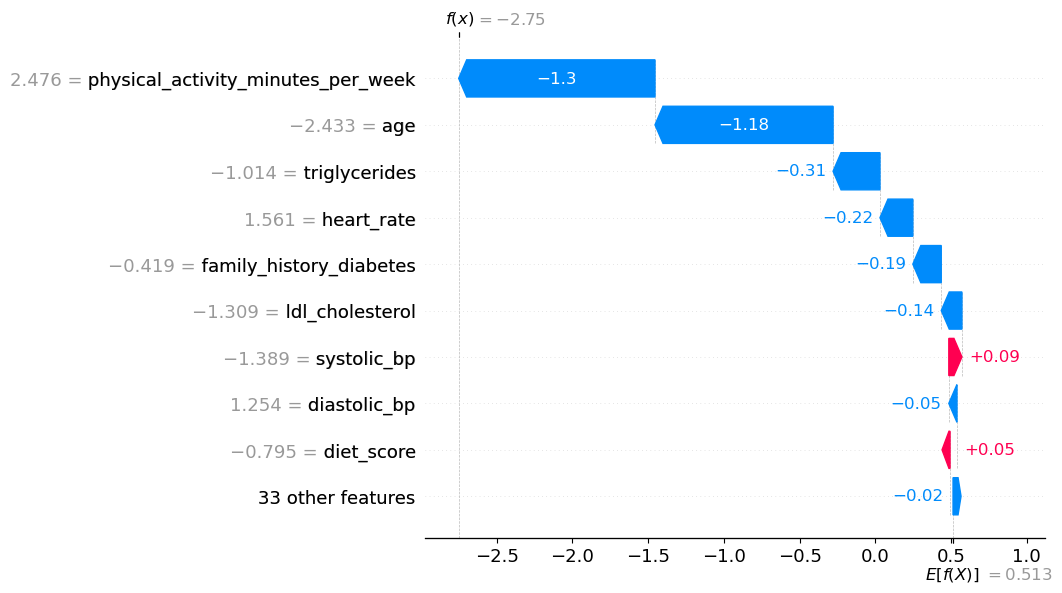

In [25]:
# ============================================================
# Comparative Case-Level Explanations
# ============================================================

print("=" * 70)
print("Comparative Explainability: High-Risk vs Low-Risk Patient")
print("=" * 70)

# ------------------------------------------------------------
# Select Patients
# ------------------------------------------------------------

high_risk = np.argmax(final_probs)
low_risk = np.argmin(final_probs)

patients = {
    "High-Risk Patient": high_risk,
    "Low-Risk Patient": low_risk
}

for title, idx in patients.items():

    print("\n" + "="*70)
    print(title)
    print("="*70)

    probability = best_xgb.predict_proba(
        X_test_df.iloc[[idx]]
    )[0,1]

    prediction = best_xgb.predict(
        X_test_df.iloc[[idx]]
    )[0]

    actual = y_test.iloc[idx]

    print(f"Patient Index         : {idx}")
    print(f"Predicted Probability : {probability:.4f}")
    print(f"Predicted Class       : {prediction}")
    print(f"Actual Class          : {actual}")

    # ----------------------------------------
    # Feature Contributions
    # ----------------------------------------

    patient_df = pd.DataFrame({

        "Feature": X_test_df.columns,

        "Feature Value": X_test_df.iloc[idx].values,

        "SHAP Value": shap_values.values[idx]

    })

    patient_df["Absolute SHAP"] = np.abs(
        patient_df["SHAP Value"]
    )

    patient_df = patient_df.sort_values(

        "Absolute SHAP",

        ascending=False

    )

    print("\nTop 10 Contributing Features")

    display(patient_df.head(10))

    # ----------------------------------------
    # Waterfall Plot
    # ----------------------------------------

    print("\nWaterfall Explanation")

    shap.plots.waterfall(
        shap_values[idx],
        max_display=10
    )

SHAP Decision Plot


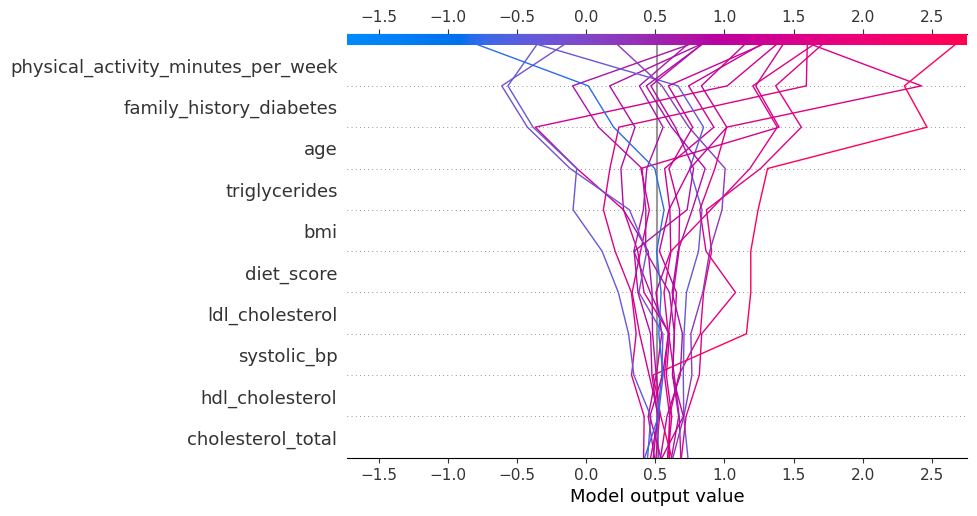

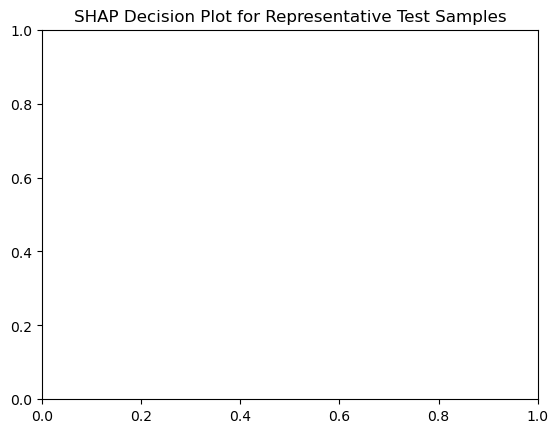

In [26]:
# ============================================================
# SHAP Decision Plot
# ============================================================

print("=" * 60)
print("SHAP Decision Plot")
print("=" * 60)

# ------------------------------------------------------------
# Select 20 representative patients
# ------------------------------------------------------------

num_samples = 20

sample_indices = np.linspace(
    0,
    len(X_test_df) - 1,
    num_samples,
    dtype=int
)

# ------------------------------------------------------------
# Decision Plot
# ------------------------------------------------------------

plt.figure(figsize=(12,8))

shap.decision_plot(
    base_value=explainer.expected_value,
    shap_values=shap_values.values[sample_indices],
    features=X_test_df.iloc[sample_indices],
    feature_names=X_test_df.columns.tolist(),
    feature_display_range=slice(None, -11, -1),
    ignore_warnings=True
)

plt.title("SHAP Decision Plot for Representative Test Samples")

plt.show()

In [27]:
# ============================================================
# SHAP Explainability for Proposed Stacking Ensemble
# ============================================================

print("=" * 70)
print("Model-Level Explainability of Proposed Stacking Ensemble")
print("=" * 70)

import shap

# ------------------------------------------------------------
# Meta Features
# ------------------------------------------------------------

meta_feature_names = [
    "XGBoost Probability",
    "LightGBM Probability",
    "MLP Probability"
]

meta_train = meta_X_train.copy()
meta_test = meta_X_test.copy()

meta_train.columns = meta_feature_names
meta_test.columns = meta_feature_names

# ------------------------------------------------------------
# SHAP Explainer for Meta Learner
# ------------------------------------------------------------

meta_explainer = shap.Explainer(
    meta_model,
    meta_train
)

meta_shap_values = meta_explainer(meta_test)

print("SHAP values computed successfully.")

Background dataset has 560000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=560000 when initializing the masker.


Model-Level Explainability of Proposed Stacking Ensemble
SHAP values computed successfully.


Meta-Learner SHAP Summary


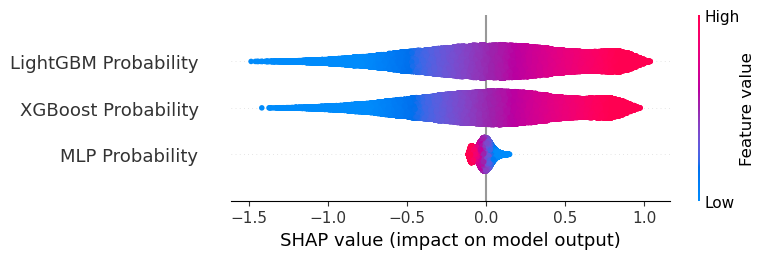

In [28]:
# ============================================================
# SHAP Summary Plot (Proposed Ensemble)
# ============================================================

print("=" * 60)
print("Meta-Learner SHAP Summary")
print("=" * 60)

shap.summary_plot(
    meta_shap_values,
    meta_test,
    show=True
)

Meta-Learner Feature Importance


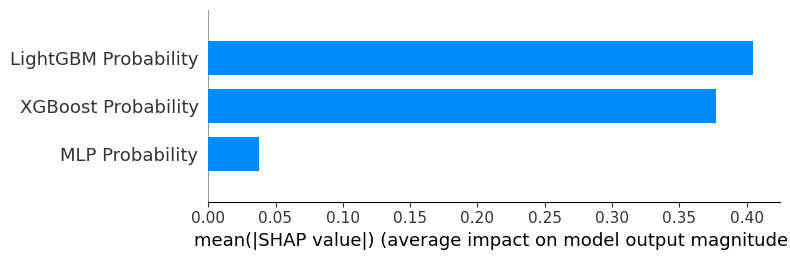

In [29]:
# ============================================================
# SHAP Feature Importance (Meta Learner)
# ============================================================

print("=" * 60)
print("Meta-Learner Feature Importance")
print("=" * 60)

shap.summary_plot(
    meta_shap_values,
    meta_test,
    plot_type="bar",
    show=True
)

In [30]:
# ============================================================
# Contribution of Base Learners
# ============================================================

importance = pd.DataFrame({

    "Base Learner": meta_feature_names,

    "Mean |SHAP|": np.abs(
        meta_shap_values.values
    ).mean(axis=0)

})

importance = importance.sort_values(

    "Mean |SHAP|",

    ascending=False

)

print("=" * 60)
print("Contribution of Each Base Learner")
print("=" * 60)

display(importance)

Contribution of Each Base Learner


,Base Learner,Mean |SHAP|
1,LightGBM Probability,0.404532
0,XGBoost Probability,0.376999
2,MLP Probability,0.037617


Waterfall Plot for Proposed Stacking Ensemble
Patient Index : 6573
Final Predicted Probability : 1.0000
Actual Class : 1.0


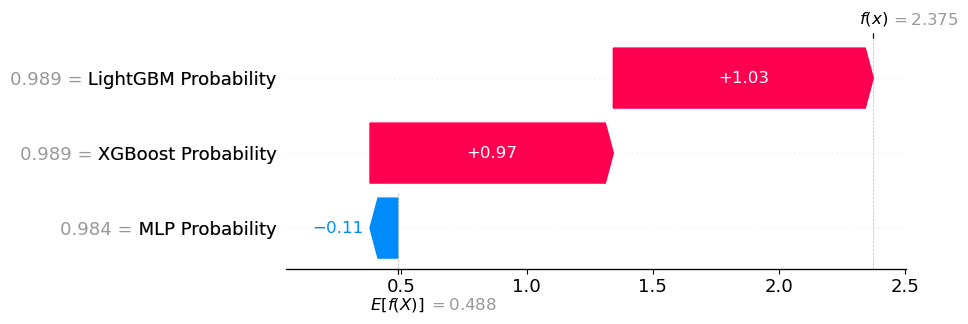

In [31]:
# ============================================================
# Waterfall Plot - Proposed Stacking Ensemble
# ============================================================

print("=" * 70)
print("Waterfall Plot for Proposed Stacking Ensemble")
print("=" * 70)

# ------------------------------------------------------------
# Select representative patient
# ------------------------------------------------------------

sample_index = np.argmax(final_probs)

print(f"Patient Index : {sample_index}")
print(f"Final Predicted Probability : {final_probs[sample_index]:.4f}")
print(f"Actual Class : {y_test.iloc[sample_index]}")

# ------------------------------------------------------------
# Waterfall Plot
# ------------------------------------------------------------

shap.plots.waterfall(
    meta_shap_values[sample_index],
    max_display=3
)